<span style="font-size:30px">**Tutorial**</span>

In this tutorial, we will explore how to construct RCA spaces from input spaces derived from MNIST images (STEP 1), and then demonstrate how to use these RCA spaces as inputs to a simple machine-learning model (STEP 2).

<span style="font-size:22px">**STEP 1: RCA generation**</span>

Let's begin by loading the MNIST dataset:

In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np

# Load MNIST (train + test separately)
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# Combine into one full dataset
X_full = np.concatenate([train_X, test_X], axis=0)
y_full = np.concatenate([train_y, test_y], axis=0)

# Take exactly 5000 samples
X_full = X_full[:5000]
X_full = X_full.reshape(len(X_full), -1).astype(float)
y_full = y_full[:5000]

2025-11-15 12:26:53.798764: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-15 12:26:53.804830: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-15 12:26:53.809618: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-15 12:26:53.820896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763209613.836205 4134581 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763209613.84

Now that the input space has been computed, the RCA spaces can be generated using the following functions:

In [8]:
from RCA_space import generate_rca_space

A,B=generate_rca_space.RCA_reference_projection(original_array=X_full,ref_array=None, k=25)
X=generate_rca_space.RCA_vectorized(A,B)

And voilà — the RCA space for the 5,000 MNIST images has now been created.
A visualisation comparing the original image and its RCA projection for the first sample in the subset is shown below, highlighting the structural differences between the two representations.

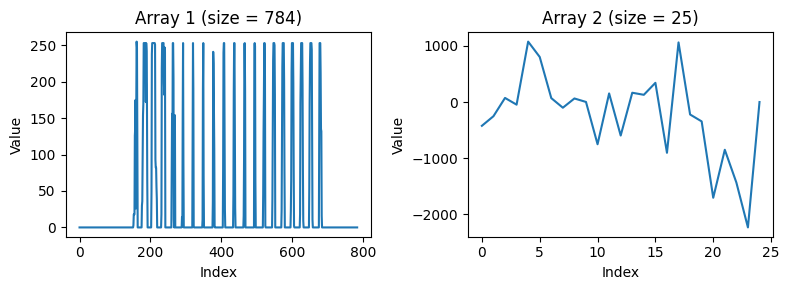

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_two_arrays_1d(arr1, arr2):
    fig, axs = plt.subplots(1, 2, figsize=(8, 3))

    # Plot array 1
    axs[0].plot(arr1)
    axs[0].set_title(f"Array 1 (size = {len(arr1)})")
    axs[0].set_xlabel("Index")
    axs[0].set_ylabel("Value")

    # Plot array 2
    axs[1].plot(arr2)
    axs[1].set_title(f"Array 2 (size = {len(arr2)})")
    axs[1].set_xlabel("Index")
    axs[1].set_ylabel("Value")

    plt.tight_layout()
    plt.show()
plot_two_arrays_1d(X_full[0], X[0])


<span style="font-size:22px">**STEP 2: ML with RCA**</span>

After constructing the RCA space, it can be used as input to machine-learning models just like any other feature space.
As a demonstration, we apply an SVR model to predict the Y_full property using both the full image space and the corresponding RCA space.

In [4]:
# ML using the full space (Classification)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
import time
from sklearn.metrics import confusion_matrix


start = time.time()

# Pipeline (scaling + SVC)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

# Hyperparameter distributions (for classification)
param_distributions = {
    'svc__C': np.logspace(-2, 3, 20),
    'svc__gamma': np.logspace(-4, 1, 20),
    'svc__kernel': ['rbf']   # best-performing kernel for text data
}

# Random search
search = RandomizedSearchCV(
    pipe,
    param_distributions=param_distributions,
    n_iter=30,        # number of sampled combinations
    cv=3,             # 3-fold CV
    scoring='accuracy',   # <-- classification score
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit on full input space
search.fit(X_full, y_full)

print("Best parameters:", search.best_params_)

# Use best model
best_model = search.best_estimator_
Y_pred = best_model.predict(X_full)

# Classification metric
acc_full = accuracy_score(y_full, Y_pred)
cm_full = confusion_matrix(y_full, Y_pred)
end = time.time()
time_full = end - start


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'svc__kernel': 'rbf', 'svc__gamma': np.float64(0.0003359818286283781), 'svc__C': np.float64(26.366508987303583)}


In [10]:
# ML using the RCA space (Classification)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
import time
from sklearn.metrics import confusion_matrix
start = time.time()

# Pipeline for RCA space
pipe_rca = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

# Hyperparameter search ranges (classification)
param_distributions_rca = {
    'svc__C': np.logspace(-2, 3, 20),
    'svc__gamma': np.logspace(-4, 1, 20),
    'svc__kernel': ['rbf']
}

# Randomized search
search_rca = RandomizedSearchCV(
    pipe_rca,
    param_distributions=param_distributions_rca,
    n_iter=30,
    cv=3,
    scoring='accuracy',     # <-- classification scoring
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit on RCA space
search_rca.fit(X, y_full)

# Best model
best_svc_rca = search_rca.best_estimator_

# Predictions
Y_pred_rca = best_svc_rca.predict(X)

# Classification metric
acc_rca = accuracy_score(y_full, Y_pred_rca)
cm_rca = confusion_matrix(y_full, Y_pred_rca)
end = time.time()
time_rca = end - start


Fitting 3 folds for each of 30 candidates, totalling 90 fits


After hyperparameter tuning and training the SVR models on both the RCA space and the full input space, the results are as follows:

In [11]:
print("----- SVR Comparison -----")
print(f"Full X_full space: accuracy_score = {acc_full:.4f}")
print(f"RCA space:        accuracy_score = {acc_rca:.4f}")

----- SVR Comparison -----
Full X_full space: accuracy_score = 0.9978
RCA space:        accuracy_score = 1.0000


A major drawback of using the full input space is the significantly longer training time required. The ratio between the hyperparameter-optimization and training times for the full space compared to the RCA space is shown below:

In [13]:
time_full/time_rca

8.387938462097415

[CV] END svc__C=4.281332398719392, svc__gamma=0.023357214690901212, svc__kernel=rbf; total time=   7.6s
[CV] END svc__C=0.018329807108324356, svc__gamma=0.26366508987303583, svc__kernel=rbf; total time=   8.0s
[CV] END svc__C=0.11288378916846889, svc__gamma=0.26366508987303583, svc__kernel=rbf; total time=   7.7s
[CV] END svc__C=0.11288378916846889, svc__gamma=0.4832930238571752, svc__kernel=rbf; total time=   8.0s
[CV] END svc__C=26.366508987303583, svc__gamma=0.00379269019073225, svc__kernel=rbf; total time=   5.0s
[CV] END svc__C=0.37926901907322497, svc__gamma=0.00379269019073225, svc__kernel=rbf; total time=   4.8s
[CV] END svc__C=545.5594781168514, svc__gamma=0.00018329807108324357, svc__kernel=rbf; total time=   2.0s
[CV] END svc__C=0.03359818286283781, svc__gamma=1.623776739188721, svc__kernel=rbf; total time=   7.9s
[CV] END svc__C=0.06158482110660264, svc__gamma=0.14384498882876628, svc__kernel=rbf; total time=   8.0s
[CV] END svc__C=0.03359818286283781, svc__gamma=0.00033598